In [ ]:
import torch
print(torch.__version__)

In [ ]:
A = torch.tensor([
    [1, 2],
    [3, 4]
])

B = torch.tensor([
    [5, 6],
    [7, 8]
])

print(A.shape)
print(B.shape)

## Operations on Matrices

In [ ]:
# A * B
# A - B
# A / B
# (2 * A) + (3 * B )

torch.add(A, B)

In [ ]:
print(torch.mul(A, B))
print("-" * 20)

print(A * B)
print("-" * 20)

print(torch.matmul(A, B))
print("-" * 20)

print(torch.matmul(B, A))
print("-" * 20)

print( A @ B )

## Transpose

In [ ]:
print(B)

print( B.T )

print("-" * 20)

print( B.T @ A )

In [ ]:
import torch

torch.manual_seed(42)
# often people use 42, 0, 123, 1234, 12345, 123456, 1234567, 12345678, 123456789

A = torch.rand(2, 3)
B = torch.rand(2, 3)

print(A.shape)
print(B.shape)

print(B.T.shape)

# (2, 3) @ (3, 2) -> (2, 2)
print( A @ B.T )

## Matrix Mean/Sum/Min/Max

In [ ]:
A = torch.rand(2, 3)
print(A)
print(torch.mean(A))

print(torch.sum(A))

print(torch.max(A))
print(torch.min(A))

## Determinant of Matrix

In [ ]:
A = torch.rand(3, 3)
print(A)

print(torch.det(A))

## Inverse of a matrix

In [ ]:
A = torch.rand(3, 3)
print(A)

print(torch.inverse(A))

## Identity matrix

In [ ]:
A = torch.eye(3)
B = torch.rand(3, 3)

print(B)
print(A)

print("-" * 20)

print( B @ A )

## creating range of values

In [ ]:
# python vs torch
print(list(range(10)))

print(torch.arange(10))

## Moving tensor to GPU

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

x = torch.tensor([1, 2, 3]).to(device)
x = x.cpu()
x = torch.tensor([1, 2, 3], device=device)

print(x)

# Multi-GPU scenario
# tensor([1, 2, 3], device='cuda:0')
# tensor([1, 2, 3], device='cuda:1')
# tensor([1, 2, 3], device='cuda:2')

## AutoGrad and Gradients
- at x = 2, y=(2)^2+3(2)+1=11
- `grad_fn` = means pytorch remembers how `y` was computed
- the process of `squaring = PowBackward0` and `addition = AddBackward0` is called the `computational graph`

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

x = torch.tensor(2.0, dtype=torch.float32, device=device, requires_grad=True)
y = (x ** 2) + (3 * x) + 1
print(y)

##
- dy/dx = 2x + 3
- dy/dx at x = 2 => 2(2) + 3 = 7

In [ ]:
# compute the  gradient of y with respect to x
y.backward()

# access the gradient
print(x.grad)

## A straight line
start off with m = 0.01, c = 0.0 (call this model weights, hyperparameters)
- y = mx + c, 
- optimal values  m = 2, c = 10
- final equation: age = 2x + 10

In [ ]:
y = 0.5
y_pred = 0.8
loss = (y_pred - y) ** 2
print(f"Loss: {loss:.2f}")

In [ ]:
y = [0.5, 0.6, 0.7]
y_pred = [0.8, 0.9, 1.0]

# list(zip(y_pred, y))

for yp, y in zip(y_pred, y):
    print(f"yp: {yp}, y: {y}")

In [ ]:
y = [0.5, 0.6, 0.7]
[x * 2 for x in y]

In [ ]:
y = [0.5, 0.6, 0.7]
y_pred = [0.8, 0.9, 1.0]
loss = 1/len(y) * sum((yp - y) ** 2 for yp, y in zip(y_pred, y))
print(f"Loss: {loss:.2f}")

In [ ]:
torch.pow(torch.tensor(4.0), 2)

In [ ]:
loss = torch.mean((torch.tensor(y_pred) - torch.tensor(y)) ** 2)
print(f"Loss: {loss:.2f}")


loss = torch.pow(torch.mean((torch.tensor(y_pred) - torch.tensor(y))), 2)
print(f"Loss: {loss:.2f}")

In [ ]:
# y = mx. y = age, x = height
# y = -2x

x = torch.tensor(1.0)
y = torch.tensor(2.0)

m = torch.tensor(1.0, requires_grad=True)

y_pred = m * x

# loss = (y_pred - y) ** 2
loss = (m * x - y) ** 2

# dloss/dm = 2 * (mx - y) * x

print(f"Loss: {loss:.2f}")

# backpropagation / backward pass to compute the gradient of loss with respect to m (dLoss/dm)
loss.backward()

# access the gradient
print(m.grad)


# continue with optimization step to update m
learning_rate = 0.01
with torch.no_grad():
    m = m - learning_rate * m.grad
    # m -= learning_rate * m.grad

# don't forget to zero the gradients after updating
# print(m.grad.zero_())


In [ ]:
a = 1
a = a - 1
a -= 1
print(a)

## Keep updating weights
- In machine learning; we choose the learning by choice `learning_rate = 0.05, 0.01, 0.5, 0.00023`
- `m = m - learning_rate * dm`
- dm = m.grad

In [ ]:
x = torch.tensor(2.0)
y = torch.tensor(4.0)

# y = m * x

m = torch.tensor(0.0, requires_grad=True)

learning_rate = 0.1 # often people use 0.01, 0.001, 0.0001
epochs = 10 # how many times we want to loop through our data

for epoch in range(epochs):

    # 1. Forward pass
    prediction = m * x # 0.5 * 2.0 = 1.0

    # 2. Loss
    loss = (prediction - y) ** 2 # (1.0 - 4.0) ** 2 = 9.0

    # 3. Backward pass (calculate gradients)
    loss.backward()

    print("Gradient:", m.grad)

    # 4. Update weights
    with torch.no_grad():
        m -= learning_rate * m.grad # m = m - learning_rate * m.grad

    # 5. Zero gradients
    m.grad.zero_() # m.grad = 0

    print(f"Updated weight: {m.item():.2f}")

In [ ]:
import numpy as np 

# Compute every step manually

# Linear regression
# y = m * x 

# here : y = 2 * x
X = np.array([1, 2, 3, 4], dtype=np.float32)
Y = np.array([2, 4, 6, 8], dtype=np.float32)

m = 0.0

# model output
def forward(x):
    return m * x # m*1, m*2, m*3, m*4

# loss = MSE
def loss(y, y_pred):
    return ((y_pred - y)**2).mean()

# J = MSE = 1/N * (m*x - y)**2
# dJ/dm = 1/N * 2x(m*x - y)
def gradient(x, y, y_pred):
    return np.mean(2*x*(y_pred - y))

print(f'Prediction before training: f(5) = {forward(5):.3f}')

# Training
learning_rate = 0.1
epochs = 100

for epoch in range(epochs):
    # predict = forward pass
    y_pred = forward(X)

    # loss
    l = loss(Y, y_pred)
    
    # calculate gradients
    dm  = gradient(X, Y, y_pred)

    # update weights
    # m = m - learning_rate * dm
    m -= learning_rate * dm

    if epoch % 2 == 0:
        print(f'epoch {epoch}: m = {m:.3f}, loss = {l:.8f}')

print(f'Prediction after training: f(5) = {forward(5):.3f}')

In [ ]:
import torch

# Here we replace the manually computed gradient with autograd

# Linear regression
# y = m * x 

# here : y = 2 * x
X = torch.tensor([1, 2, 3, 4], dtype=torch.float32)
Y = torch.tensor([2, 4, 6, 8], dtype=torch.float32)

m = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)

# model output
def forward(x):
    return m * x

# loss = MSE
def loss(y, y_pred):
    return ((y_pred - y)**2).mean()

print(f'Prediction before training: f(5) = {forward(5).item():.3f}')

# Training
learning_rate = 0.01
epochs = 100

for epoch in range(epochs):
    # predict = forward pass
    y_pred = forward(X)

    # loss
    l = loss(Y, y_pred)

    # calculate gradients = backward pass
    l.backward()

    # update weights
    # m.data = m.data - learning_rate * m.grad
    with torch.no_grad():
        m -= learning_rate * m.grad
    
    # zero the gradients after updating
    m.grad.zero_()

    if epoch % 10 == 0:
        print(f'epoch {epoch}: m = {m.item():.3f}, loss = {l.item():.8f}')

print(f'Prediction after training: y(5) = {forward(5).item():.3f}')

In [ ]:
# 1) Design model (input, output, forward pass with different layers)
# 2) Construct loss and optimizer
# 3) Training loop
#       - Forward = compute prediction and loss
#       - Backward = compute gradients
#       - Update weights

import torch
import torch.nn as nn

# Linear regression
# f = w * x 

# here : f = 2 * x

# 0) Training samples
X = torch.tensor([1, 2, 3, 4], dtype=torch.float32)
Y = torch.tensor([2, 4, 6, 8], dtype=torch.float32)

# 1) Design Model: Weights to optimize and forward function
w = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)

def forward(x):
    return w * x

print(f'Prediction before training: f(5) = {forward(5).item():.3f}')

# 2) Define loss and optimizer
learning_rate = 0.01
epochs = 100

# callable function
loss = nn.MSELoss()
# loss = 1/N*sum((y_pred - y)**2)

optimizer = torch.optim.SGD([w], lr=learning_rate) # SGD = Stochastic Gradient Descent
# w = w - learning_rate * w.grad

# 3) Training loop
for epoch in range(epochs):
    # predict = forward pass
    y_predicted = forward(X)

    # loss
    l = loss(Y, y_predicted)

    # calculate gradients = backward pass
    l.backward()

    # update weights
    optimizer.step() # w = w - learning_rate * w.grad

    # zero the gradients after updating
    optimizer.zero_grad()

    if epoch % 5 == 0:
        print('epoch ', epoch, ': w = ', w.item(), ' loss = ', l.item())

print(f'Prediction after training: f(5) = {forward(5).item():.3f}')

In [3]:
!uv add scikit-learn matplotlib -q

In [4]:
import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

In [5]:
# 0) Prepare data
X, y = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=4)

Text(0, 0.5, 'y')

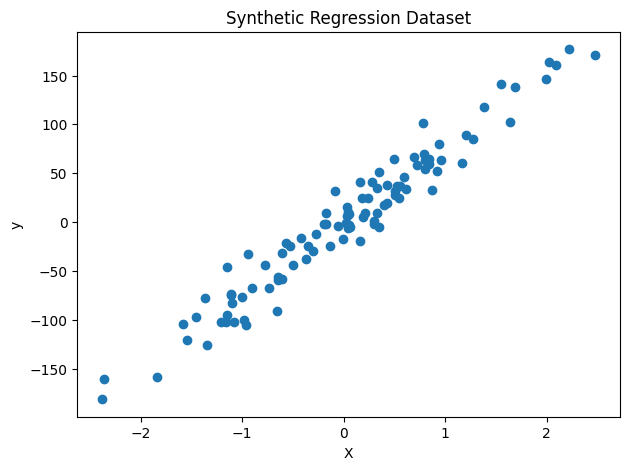

In [6]:
# Create plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X, y)

ax.set_title("Synthetic Regression Dataset")
ax.set_xlabel("X")
ax.set_ylabel("y")

In [7]:
# cast to float Tensor
X = torch.from_numpy(X.astype(np.float32))
y = torch.from_numpy(y.astype(np.float32))

In [8]:
y = y.view(y.shape[0], 1)

n_samples, n_features = X.shape

In [10]:
y.shape

torch.Size([100, 1])

In [11]:
X.shape

torch.Size([100, 1])

epoch: 10, loss = 4060.9678
epoch: 20, loss = 2861.0276
epoch: 30, loss = 2043.2993
epoch: 40, loss = 1485.9165
epoch: 50, loss = 1105.9094
epoch: 60, loss = 846.7770
epoch: 70, loss = 670.0344
epoch: 80, loss = 549.4622
epoch: 90, loss = 467.1920
epoch: 100, loss = 411.0459
epoch: 110, loss = 372.7213
epoch: 120, loss = 346.5562
epoch: 130, loss = 328.6897
epoch: 140, loss = 316.4877
epoch: 150, loss = 308.1529
epoch: 160, loss = 302.4585
epoch: 170, loss = 298.5675
epoch: 180, loss = 295.9084
epoch: 190, loss = 294.0909
epoch: 200, loss = 292.8484


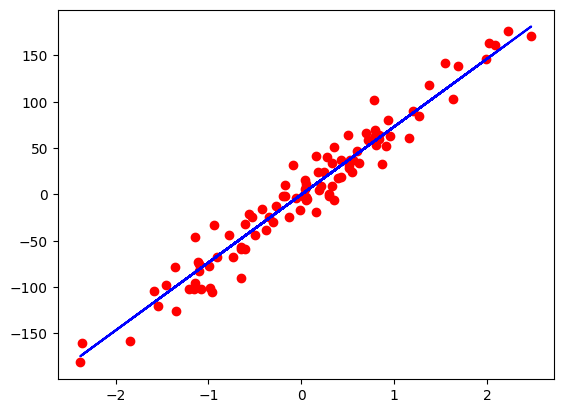

In [17]:
# 1) Model
# Linear model f = wx + b
input_size = n_features
output_size = 1

# def forwad(x): return m * x + b
model = nn.Linear(input_size, output_size)

# 2) Loss and optimizer
learning_rate = 0.01

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  

# 3) Training loop
num_epochs = 200
for epoch in range(num_epochs):
    # Forward pass and loss
    y_predicted = model(X)

    # loss
    loss = loss_fn(y_predicted, y)
    
    # Backward pass and update
    loss.backward() # compute gradients
    optimizer.step() # w = w - learning_rate * w.grad

    # zero grad before new step
    optimizer.zero_grad()

    if (epoch+1) % 10 == 0:
        print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')

# Plot
predicted = model(X).detach().numpy()

plt.plot(X, y, 'ro') # original data
plt.plot(X, predicted, 'b') # predicted data
plt.show()